This notebook constructs a model of a simple quantum reservoir computer and uses it to predict the evolution of the logistic map.

In [1]:
import math
import sys

import numpy as np
import matplotlib.pyplot as plt


First we define some useful linear algebra methods, following the construction of a classical ESN from the RC Bootcamp.

In [2]:
class Module(object):
    def __init__(self, *_args, seed=None, rnd=None, dtype=np.float64, **_kwargs):
        if rnd is None:
            self.rnd = np.random.default_rng(seed)
        else:
            self.rnd = rnd
        self.dtype = dtype


class Linear(Module):
    def __init__(self, input_dim: int, output_dim: int, bound: float = None, bias: float = 0.0, **kwargs):
        """
        Linear model

        Args:
            input_dim (int): input dimension
            output_dim (int): output dimension
            bound (float, optional): sampling scale for weight. Defaults to None.
            bias (float, optional): sampling scale for bias. Defaults to 0.0.
        """
        super(Linear, self).__init__(**kwargs)
        self.input_dim = input_dim
        self.output_dim = output_dim
        if bound is None:
            bound = math.sqrt(1 / input_dim)
        self.weight = self.rnd.uniform(-bound, bound, (output_dim, input_dim)).astype(self.dtype)
        self.bias = self.rnd.uniform(-bias, bias, (output_dim,)).astype(self.dtype)

    def __call__(self, x: np.ndarray):
        x = np.asarray(x)
        out = np.matmul(x, self.weight.swapaxes(-1, -2)) + self.bias
        return out


def solution(input_dim, output_dim, seed, bound, bias, mat):
    lin = Linear(input_dim, output_dim, bound=bound, bias=bias, seed=seed)
    return lin(mat)

In [3]:
class LRReadout(Linear):
    def train(self, x: np.ndarray, y: np.ndarray):
        assert (x.ndim == 2) and (x.shape[-1] == self.input_dim)
        assert (y.ndim == 2) and (y.shape[-1] == self.output_dim)
        # Calculate the optimal weight and bias.
        x_biased = np.ones((x.shape[0], x.shape[1] + 1), dtype=self.dtype)
        x_biased[:, 1:] = x
        sol, _residuals, _rank, _s = np.linalg.lstsq(x_biased, y, rcond=None)
        self.weight[:] = sol[1:].T
        self.bias[:] = sol[0]
        return self.weight, self.bias


def solution(dim_in, dim_out, x_train, y_train, x_eval):
    readout = LRReadout(dim_in, dim_out)
    readout.train(x_train, y_train)
    return readout(x_eval)

In [4]:
def calc_nrmse(y, yhat):
    mse = y - yhat
    mse = (mse * mse).mean(axis=0)
    var = y.var(axis=0)
    return (mse / var) ** 0.5


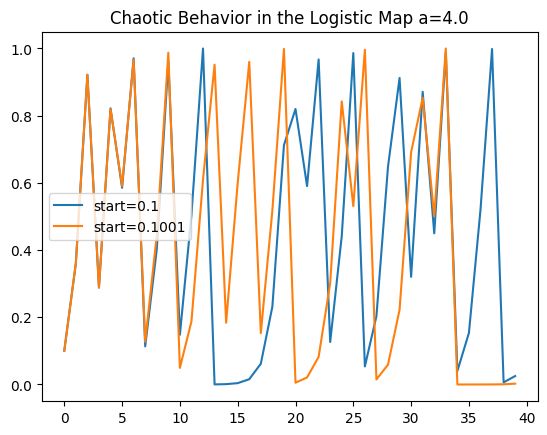

In [5]:
def logistic_func(z, a=4.0):
    z_dot = a * z * (1 - z)
    return z_dot

def generate_logistic_series(start=0.1,a=4.0,length=100):
    series = [start]
    for _ in range(length - 1):
        next_value = logistic_func(series[-1], a)
        series.append(next_value)
    return series

a=4.0
x_series = generate_logistic_series(0.1,a,40)
y_series = generate_logistic_series(0.1001,a,40)


plt.plot(x_series, label="start=0.1")
plt.plot(y_series, label="start=0.1001")
plt.title("Chaotic Behavior in the Logistic Map a="+ str(a))
plt.legend()
plt.show()



Lets create the Use an example Quantum Reservoir Computer to predict the next step in the sequence, given as input all preceeding terms in the sequence.

The input will C-Not with the first internal state, which then C-Nots with the next internal state, etc. We use 5 nodes in this system. Since this system is only in superposition of 1 and 0 on the qubits with no phase, we can model the superposition as the probability of being between 0 and 1.

So that the system does not completely settle at 1/2 probability, we use a system in which there is a chance of the state collapsing into the 0 state after every time step (the system decays with some probability). Two cycles of this system, with inputs q<sub>0</sub> and q<sub>0</sub>', are shown below
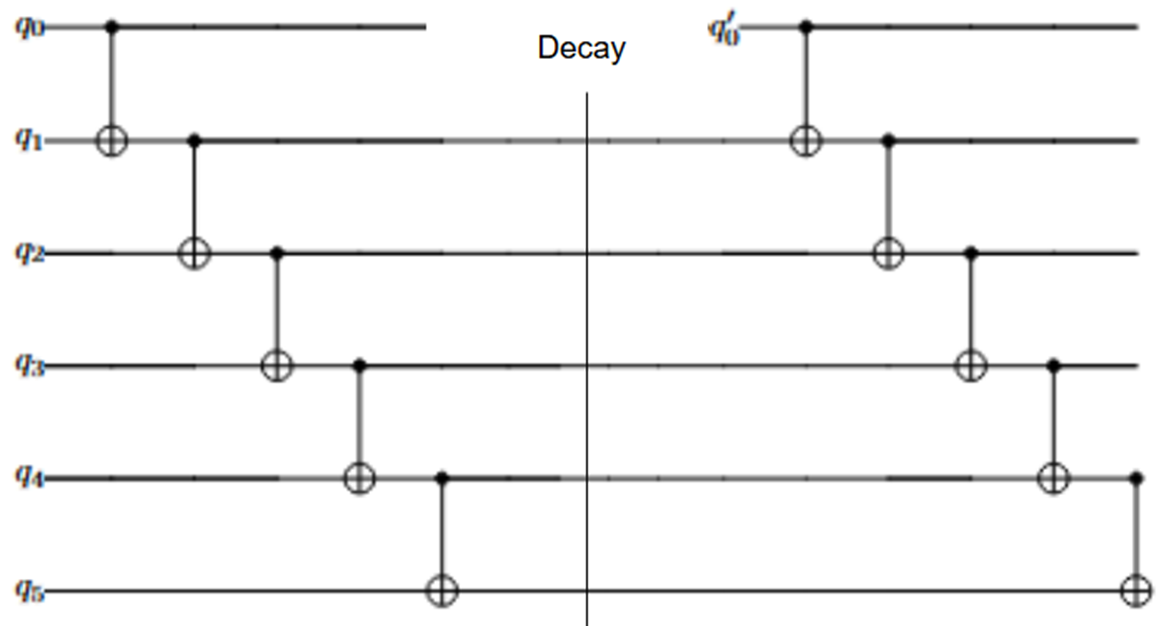

In [6]:
def update_QR(x,input,decay):
  x=x*decay
  x[0] = x[0]*(1-input)+input*(1-x[0]) #representation of C-Not
  for idn in range(1,num_nodes):
    x[idn] = x[idn]*(1-x[idn-1]) + x[idn-1]*(1-x[idn])
  return x


An alternative version involves applying another C-Not, in this case from q<sub>1</sub> to q<sub>4</sub> . This provides more variation to the later qubits, which tend closer to 50%-50% superposition than the earlier qubits.

In [7]:
def update_QR(x,input,decay):
  x=x*decay
  x[0] = x[0]*(1-input)+input*(1-x[0]) #representation of C-Not
  for idn in range(1,num_nodes):
    x[idn] = x[idn]*(1-x[idn-1]) + x[idn-1]*(1-x[idn])
    if (idn % 3 == 0):
      x[idn] = x[idn]*(1-x[0]) + x[0]*(1-x[idn])
  return x

Now train the linear readout on the output and test it using values from later in the sequence.

In [8]:
rnd = np.random.default_rng(1234)
t_washout, t_train, t_eval = 10, 200, 100
t_total = t_washout + t_train + t_eval
num_nodes = 5            #change parameters here for experimentation, or mess with the construction of the reservoir update above
a=3.7
decay=0.5

ts = np.arange(-t_washout, t_train + t_eval)
ser = np.array(generate_logistic_series(0.1,a,t_total+1)).reshape(-1,1)

w_out = LRReadout(num_nodes, 1)

ys = ser[1:]          # shape (t_total, 1)
us = ser[:-1]         # shape (t_total, 1)

x=np.zeros(num_nodes) #start the reservoir at 0
xs = np.zeros((t_total, num_nodes))
for idx in range(t_total):
    x=update_QR(x,us[idx],decay)
    xs[idx] = x


x_train, y_train = xs[t_washout:-t_eval], ys[t_washout:-t_eval]
x_eval, y_eval = xs[-t_eval:], ys[-t_eval:]
w_out.train(x_train, y_train)
y_out = w_out(x_eval)
nrmse = calc_nrmse(y_eval, y_out)


None

/tmp/ipykernel_7125/2486740956.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x[0] = x[0]*(1-input)+input*(1-x[0]) #representation of C-Not


Text(0.5, 0, 'time steps')

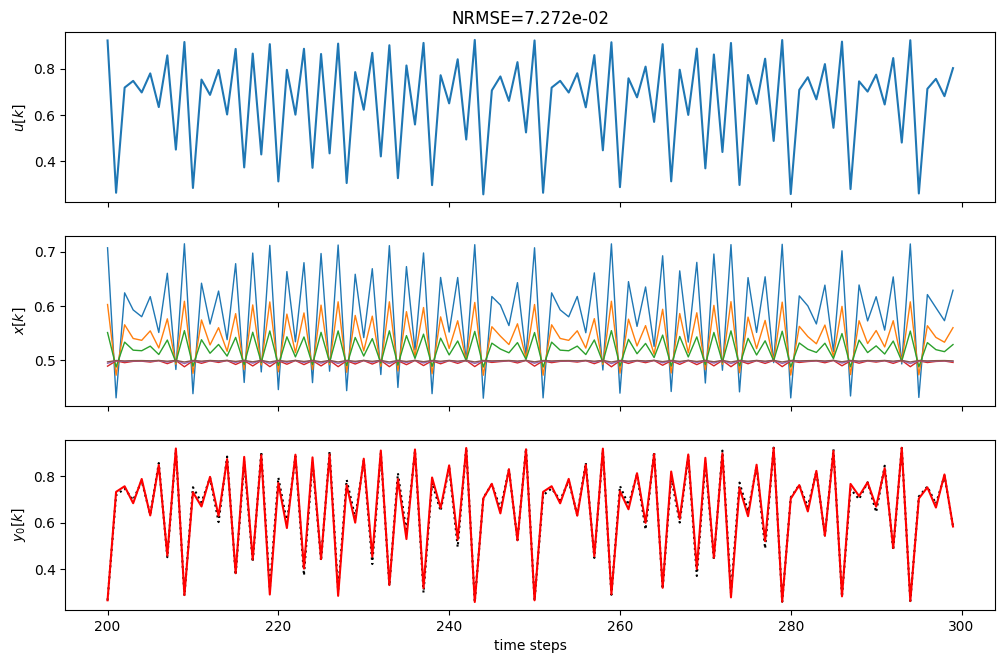

In [11]:
plot_length = min(200,t_eval)
num_extra_series = y_out.shape[1] if y_out.ndim > 1 else 1

# Total subplots:
# 1 for u, 1 for xs (all together), + one per output series
n_plots = 2 + num_extra_series

fig, ax = plt.subplots(n_plots, 1, figsize=(12, 2.5*n_plots),
                       gridspec_kw={"hspace": 0.2})

# --- Input ---
ax[0].plot(ts[-plot_length:], us[-plot_length:])
ax[0].set_ylabel(r"$u[k]$")
ax[0].set_xticklabels([])
ax[0].set_title(f"NRMSE={nrmse[0]:.3e}")

# --- Internal ESN states (ALL on one plot) ---
ax[1].plot(ts[-plot_length:], xs[-plot_length:], lw=1.0)
ax[1].set_ylabel(r"$x[k]$")
ax[1].set_xticklabels([])

# --- Outputs (separate plots) ---
for i in range(num_extra_series):
    idx = i + 2

    if num_extra_series == 1:
        y_out_i = y_out[-plot_length:]
        y_eval_i = y_eval[-plot_length:]
    else:
        y_out_i = y_out[-plot_length:, i]
        y_eval_i = y_eval[-plot_length:, i]

    ax[idx].plot(ts[-plot_length:], y_eval_i, color="k", ls=":", lw=1.5)
    ax[idx].plot(ts[-plot_length:], y_out_i, color="red", lw=1.5)

    ax[idx].set_ylabel(f"$y_{i}[k]$")
    if i < num_extra_series - 1:
        ax[idx].set_xticklabels([])

ax[-1].set_xlabel("time steps")

Now we feed the output of the trained Quantum Reservoir Computer as the next input. This predicts the sequence for multiple steps  

/tmp/ipykernel_7125/2486740956.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x[0] = x[0]*(1-input)+input*(1-x[0]) #representation of C-Not


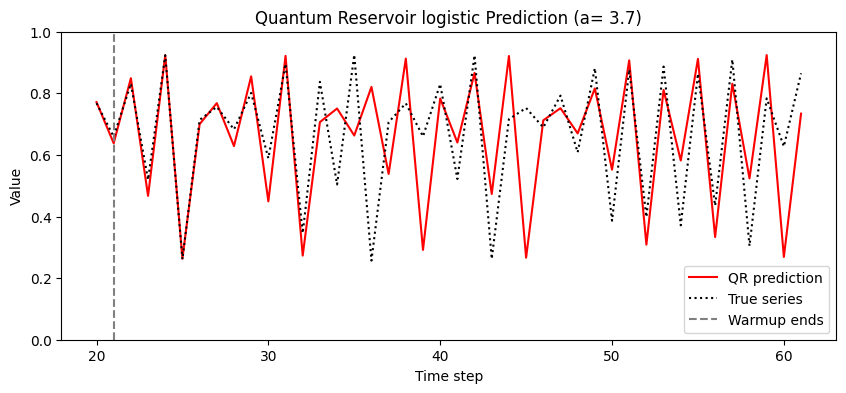

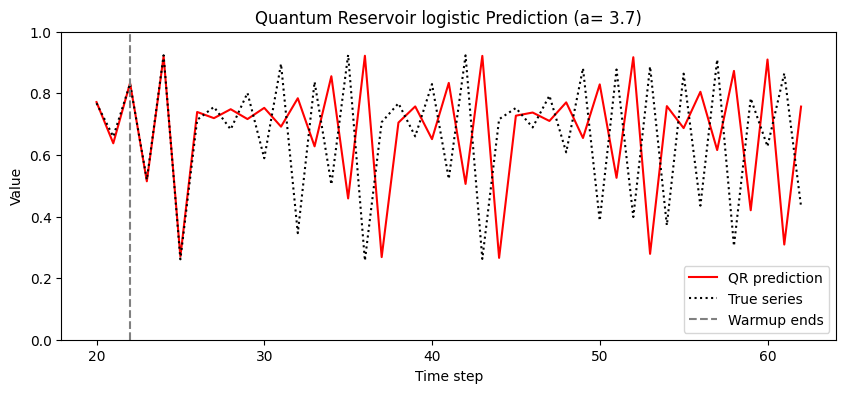

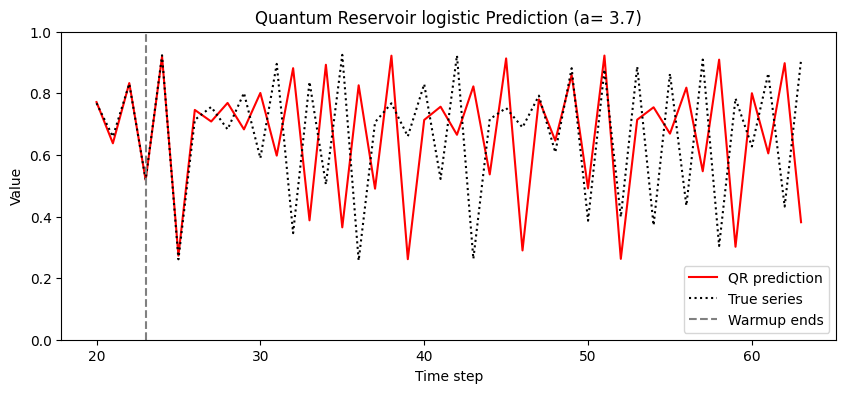

In [12]:
for w_ind in range(3):
  # --- Parameters ---
  warmup_steps = 22+1*w_ind       #simulate random initial conditions by starting prediction at different indices
  pred_steps = 40
  t_total = warmup_steps + pred_steps

  # --- Prepare storage ---
  x = np.zeros(num_nodes)                # initial reservoir state
  y_gen = np.zeros((t_total, 1))   # generated output
  u = 0

  # --- Warmup: feed real inputs to settle reservoir ---
  for idx in range(warmup_steps):
      x = update_QR(x,us[idx],decay)    # update reservoir
      y_pred = w_out(x)            # compute output (optional)
      y_gen[idx] = y_pred          # store predicted output for warmup

  # --- Closed-loop prediction ---
  for idx in range(warmup_steps, t_total):
      u = y_pred                   # feed prediction as next input
      x = update_QR(x,u,decay)         # update reservoir with last output
      y_pred = w_out(x)            # predict next step
      y_gen[idx] = y_pred          # store prediction

  # --- Plot results starting after 20 steps ---
  plot_start = 20
  plt.figure(figsize=(10,4))
  time_steps = np.arange(plot_start, t_total)

  plt.plot(time_steps, y_gen[plot_start:], 'r', label='QR prediction')
  plt.plot(time_steps, ys[plot_start:t_total], 'k:', label='True series')

  plt.axvline(warmup_steps - 1, color='gray', linestyle='--', label='Warmup ends')

  plt.xlabel('Time step')
  plt.ylabel('Value')
  plt.title('Quantum Reservoir logistic Prediction (a= '+ str(a) + ')')

  plt.ylim(0, 1)  # <-- set y-axis range

  plt.legend()
  plt.show()